In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


In [ ]:
df = pd.read_csv('train.csv')
print("Checking first 5 rows: ", df.head()) #show first 5 rows on csv.

print()
print("Checking datatypes: ",df.info()) #show datatypes , missing values, etc.
#no missing values. 2000 rows of data.

print()
print("Checking category: ",df['price_range'].value_counts()) #check pricerange of each category
#500 data per category.

Checking first 5 rows:     battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  to

In [ ]:
target = 'price_range'
x = df.drop(columns=[target])
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state = 42 , test_size = 0.3)
#since 30% testing, so test size = 0.3


rf = RandomForestClassifier(n_estimators= 100, max_depth=10 , random_state=42 , n_jobs=1 )
#n_estimators = num of decision trees in forest
# random_state = ensure reporducable results
#max_depth = how deep each tree can go.
#n_jobs = how many trees can be trained at once.
rf.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, n_jobs=1, random_state=42)

Accuracy:  0.8566666666666667
f1 macro:  0.8560760464872691
f1 weighted:  0.8570079812511434


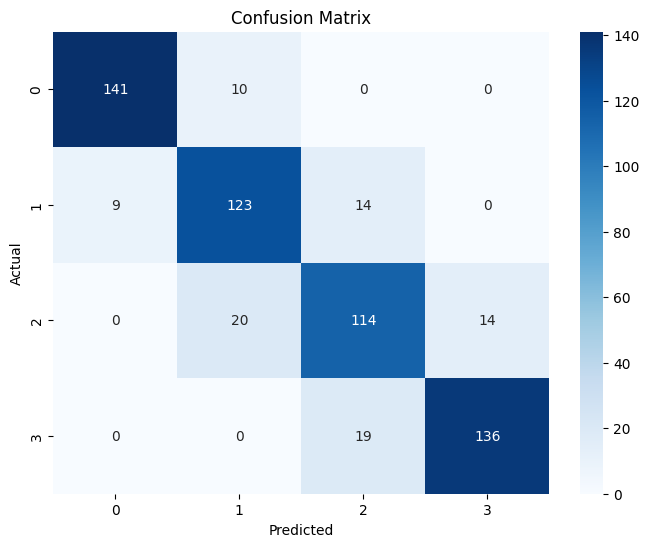

In [ ]:
y_pred = rf.predict(x_test)

#accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

#f1 scores
f1_macro = f1_score(y_test, y_pred, average = "macro")
f1_weighted = f1_score(y_test, y_pred, average = "weighted")
print("f1 macro: ", f1_macro)
print("f1 weighted: ", f1_weighted)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt= 'd', cmap= 'Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# this should connect to the front end.

battery_power = input("Battery Power: ")
bluetooth = input("bluetooth (1 = yes, 0 = no): ")
clock_speed= input("Clockspeed(GHz): ")
dual_sim= input("Dual_sim (1 = yes, 0 = no): ")
front_camera= input("front camera: ")
four_g= input(" four g (1 = yes, 0 = no): ")
int_memory= input("memory (GB): ")
mobile_depth= input("mobile depth(cm) : ")
mobile_wt= input("mobile wt (grams): ")
n_cores= input("n cores: ")
primary_camera= input("Primary Camera : ")
px_height= input("pixel height: ")
px_width= input("pixel width: ")
ram= input("RAM (mb): ")
screen_height= input("screen height (inches): ")
screen_width= input("screen width (inches): ")
talk_time= input("talk time (hours): ")
three_g= input(" three g (1 = yes, 0 = no): ")
touch_screen= input(" touch screen (1 = yes, 0 = no): ")
wifi= input(" wifi (1 = yes, 0 = no): ")

predicted_price_level = rf.predict([new_phone_features])[0]

price_mapping = {0: "Low", 1: "Medium", 2: "High", 3: "Very High"}
predicted_label = price_mapping.get(predicted_price_level, predicted_price_level)

print(f"\nPredicted price range: Level ", predicted_price_level)
print(f"Price category: ", predicted_label)

probabilities = rf.predict_proba([new_phone_features])[0]
print(f"\nPrediction probabilities per class:")
for i, prob in enumerate(probabilities):
    print(f"  Level {i} ({price_mapping.get(i, i)}): {prob:.2%}")


Predicted price range: Level  3
Price category:  Very High

Prediction probabilities per class:
  Level 0 (Low): 4.03%
  Level 1 (Medium): 8.47%
  Level 2 (High): 12.27%
  Level 3 (Very High): 75.24%


c:\Users\Ewika\Desktop\Binus Folders\Machine Learning\environments\deep_learning\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ewika\Desktop\Binus Folders\Machine Learning\environments\deep_learning\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
